## 📐 Mean, Variance & Standard Deviation Calculator

[![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-blue?logo=google-colab&style=flat-square)](https://colab.research.google.com/drive/1ooFNF91BcRPpAoUn5GG9XC2DP5pCbF2j?usp=sharing)

### Overview

This notebook implements and visualizes a statistical calculator that takes a **list of 9 numbers**, reshapes it into a **3×3 matrix**, and computes:

| Statistic | Along Columns | Along Rows | Flattened |
|-----------|:-------------:|:----------:|:---------:|
| Mean | ✓ | ✓ | ✓ |
| Variance | ✓ | ✓ | ✓ |
| Std Dev | ✓ | ✓ | ✓ |
| Max | ✓ | ✓ | ✓ |
| Min | ✓ | ✓ | ✓ |
| Sum | ✓ | ✓ | ✓ |

### Tools & Techniques

- **NumPy** for matrix operations and statistical calculations.
- **Matplotlib** and **Seaborn** for visualizing the results.

In [19]:
# Imported the required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

### 🔧 1. Function Implementation

The `calculate()` function:
1. Validates the input has exactly 9 elements
2. Reshapes the list into a 3×3 NumPy matrix
3. Computes 6 statistics along both axes and for the whole matrix
4. Returns all results in a structured dictionary

In [20]:
def calculate(lst: list) -> dict:
    """
    Compute mean, variance, standard deviation, max, min, and sum
    of a list of 9 numbers arranged in a 3x3 matrix.

    Args:
        lst (list): A list containing exactly 9 numbers.

    Returns:
        dict: Statistics along axis-0 (columns), axis-1 (rows), and flattened.

    Raises:
        ValueError: If the list does not contain exactly 9 numbers.
    """
    if len(lst) != 9:
        raise ValueError("List must contain nine numbers.")

    matrix = np.array(lst).reshape(3, 3)
    print("Matrix:\n", matrix)  # Debugging line to check the matrix
    print("Matrix shape:", matrix.shape)  # Debugging line to check the shape of the matrix 

    mean = [matrix.mean(axis=0).tolist(), matrix.mean(axis=1).tolist(), matrix.mean().tolist()] # axis=0 for columns, axis=1 for rows, and no axis for the entire matrix
    variance = [matrix.var(axis=0).tolist(), matrix.var(axis=1).tolist(), matrix.var().tolist()]
    std_dev = [matrix.std(axis=0).tolist(), matrix.std(axis=1).tolist(), matrix.std().tolist()]
    max_val = [matrix.max(axis=0).tolist(), matrix.max(axis=1).tolist(), matrix.max().tolist()]
    min_val = [matrix.min(axis=0).tolist(), matrix.min(axis=1).tolist(), matrix.min().tolist()]
    sum_val = [matrix.sum(axis=0).tolist(), matrix.sum(axis=1).tolist(), matrix.sum().tolist()]


    calculations = {
        'mean': mean,
        'variance': variance,
        'standard deviation': std_dev,
        'max': max_val,
        'min': min_val,
        'sum': sum_val
    }

    return calculations

### 🔢 2. Matrix Visualization

Reshaping the canonical example `[0, 1, 2, 3, 4, 5, 6, 7, 8]` into a 3×3 matrix and annotating it visually.

Input list  : [0, 1, 2, 3, 4, 5, 6, 7, 8]
3x3 matrix  :
 [[0 1 2]
 [3 4 5]
 [6 7 8]]


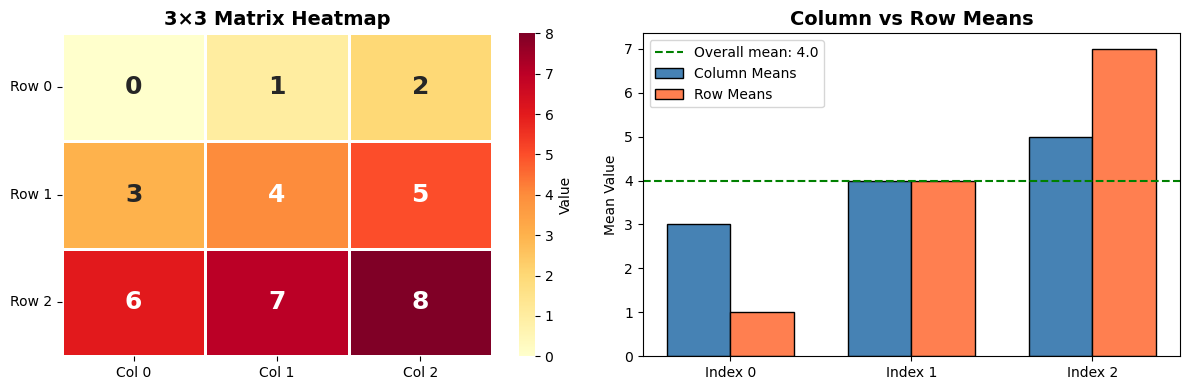

In [21]:
example_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]
matrix       = np.array(example_list).reshape(3, 3)

print("Input list  :", example_list)
print("3x3 matrix  :\n", matrix)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap of the matrix values
sns.heatmap(
    matrix, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=2, linecolor='white', ax=axes[0],
    cbar_kws={'label': 'Value'}, annot_kws={'size': 18, 'weight': 'bold'}
)
axes[0].set_title('3×3 Matrix Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
axes[0].set_yticklabels(['Row 0', 'Row 1', 'Row 2'], rotation=0)

# Column-wise vs Row-wise means
col_means = matrix.mean(axis=0)
row_means = matrix.mean(axis=1)
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, col_means, width, label='Column Means', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, row_means, width, label='Row Means', color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Index 0', 'Index 1', 'Index 2'])
axes[1].set_title('Column vs Row Means', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Value')
axes[1].legend()
axes[1].axhline(matrix.mean(), color='green', linestyle='--', linewidth=1.5,
                label=f'Overall mean: {matrix.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 3. Full Statistical Analysis

Running `calculate()` on the example and displaying each statistic clearly.

In [22]:
result = calculate(example_list)

print("=" * 60)
print("  STATISTICAL RESULTS FOR [0, 1, 2, 3, 4, 5, 6, 7, 8]")
print("=" * 60)
print(f"{'Statistic':<22} {'Axis-0 (cols)':<22} {'Axis-1 (rows)':<22} {'Flattened'}")
print("-" * 88)
for stat, values in result.items():
    col_vals = str([f'{v:.2f}' if isinstance(v, float) else v for v in values[0]])
    row_vals = str([f'{v:.2f}' if isinstance(v, float) else v for v in values[1]])
    flat_val = f'{values[2]:.4f}' if isinstance(values[2], float) else str(values[2])
    print(f"{stat:<22} {col_vals:<22} {row_vals:<22} {flat_val}")

Matrix:
 [[0 1 2]
 [3 4 5]
 [6 7 8]]
Matrix shape: (3, 3)
  STATISTICAL RESULTS FOR [0, 1, 2, 3, 4, 5, 6, 7, 8]
Statistic              Axis-0 (cols)          Axis-1 (rows)          Flattened
----------------------------------------------------------------------------------------
mean                   ['3.00', '4.00', '5.00'] ['1.00', '4.00', '7.00'] 4.0000
variance               ['6.00', '6.00', '6.00'] ['0.67', '0.67', '0.67'] 6.6667
standard deviation     ['2.45', '2.45', '2.45'] ['0.82', '0.82', '0.82'] 2.5820
max                    [6, 7, 8]              [2, 5, 8]              8
min                    [0, 1, 2]              [0, 3, 6]              0
sum                    [9, 12, 15]            [3, 12, 21]            36


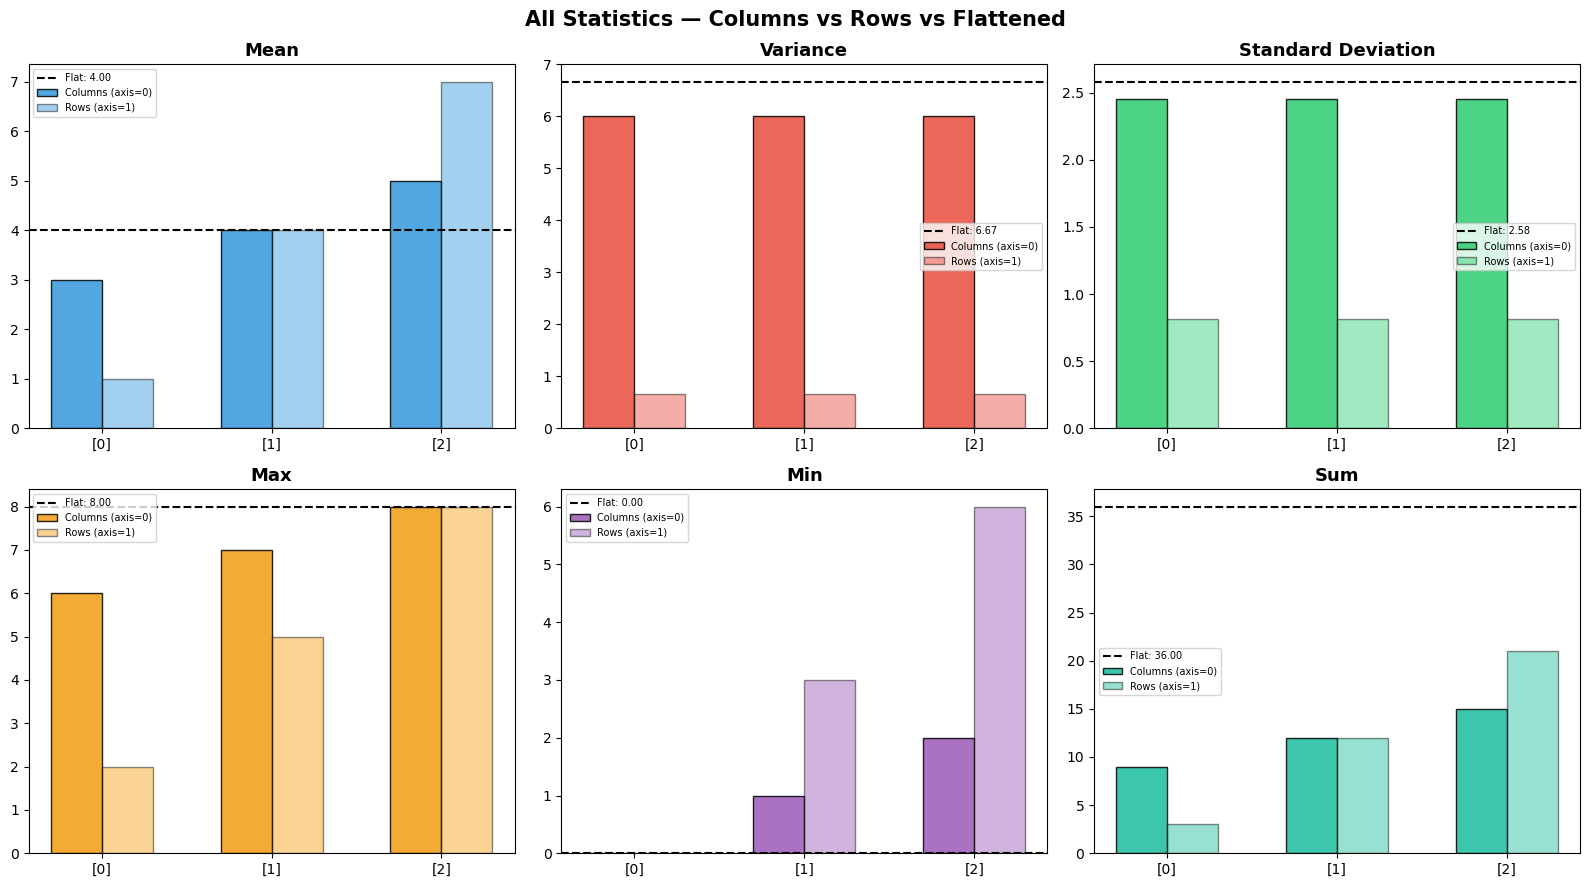

In [23]:
# Visual comparison of all statistics across axes
stats_to_plot = ['mean', 'variance', 'standard deviation', 'max', 'min', 'sum']
colors        = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (stat, color) in enumerate(zip(stats_to_plot, colors)):
    col_vals  = result[stat][0]
    row_vals  = result[stat][1]
    flat_val  = result[stat][2]
    x = np.arange(3)
    width = 0.3

    axes[i].bar(x - width, col_vals, width, label='Columns (axis=0)',
                color=color, alpha=0.85, edgecolor='black')
    axes[i].bar(x,         row_vals, width, label='Rows (axis=1)',
                color=color, alpha=0.45, edgecolor='black')
    axes[i].axhline(flat_val, color='black', linestyle='--', linewidth=1.5,
                    label=f'Flat: {flat_val:.2f}')
    axes[i].set_title(stat.title(), fontsize=13, fontweight='bold')
    axes[i].set_xticks(x - width/2)
    axes[i].set_xticklabels(['[0]', '[1]', '[2]'])
    axes[i].legend(fontsize=7)

plt.suptitle('All Statistics — Columns vs Rows vs Flattened', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 4. Error Handling Validation

Confirming that the function raises `ValueError` for inputs that do not contain exactly 9 elements.

In [24]:
# Test with too few elements
try:
    calculate([1, 2, 3])
except ValueError as e:
    print(f"Caught ValueError for 3 elements  : {e} ✓")

# Test with too many elements
try:
    calculate(list(range(12)))
except ValueError as e:
    print(f"Caught ValueError for 12 elements : {e} ✓")

# Test with exactly 9 elements
try:
    result_valid = calculate([9, 8, 7, 6, 5, 4, 3, 2, 1])
    print(f"Valid 9-element list accepted     : ✓")
except ValueError as e:
    print(f"Unexpected error: {e}")

Caught ValueError for 3 elements  : List must contain nine numbers. ✓
Caught ValueError for 12 elements : List must contain nine numbers. ✓
Matrix:
 [[9 8 7]
 [6 5 4]
 [3 2 1]]
Matrix shape: (3, 3)
Valid 9-element list accepted     : ✓


### 🎲 5. Interactive Exploration

Comparing the statistics for multiple different input lists to observe how different data patterns affect the results.

Matrix:
 [[0 1 2]
 [3 4 5]
 [6 7 8]]
Matrix shape: (3, 3)
Matrix:
 [[5 5 5]
 [5 5 5]
 [5 5 5]]
Matrix shape: (3, 3)
Matrix:
 [[8 7 6]
 [5 4 3]
 [2 1 0]]
Matrix shape: (3, 3)
Matrix:
 [[1 0 0]
 [0 1 0]
 [0 0 1]]
Matrix shape: (3, 3)
Matrix:
 [[  0   0   0]
 [  0  50   0]
 [  0   0 100]]
Matrix shape: (3, 3)


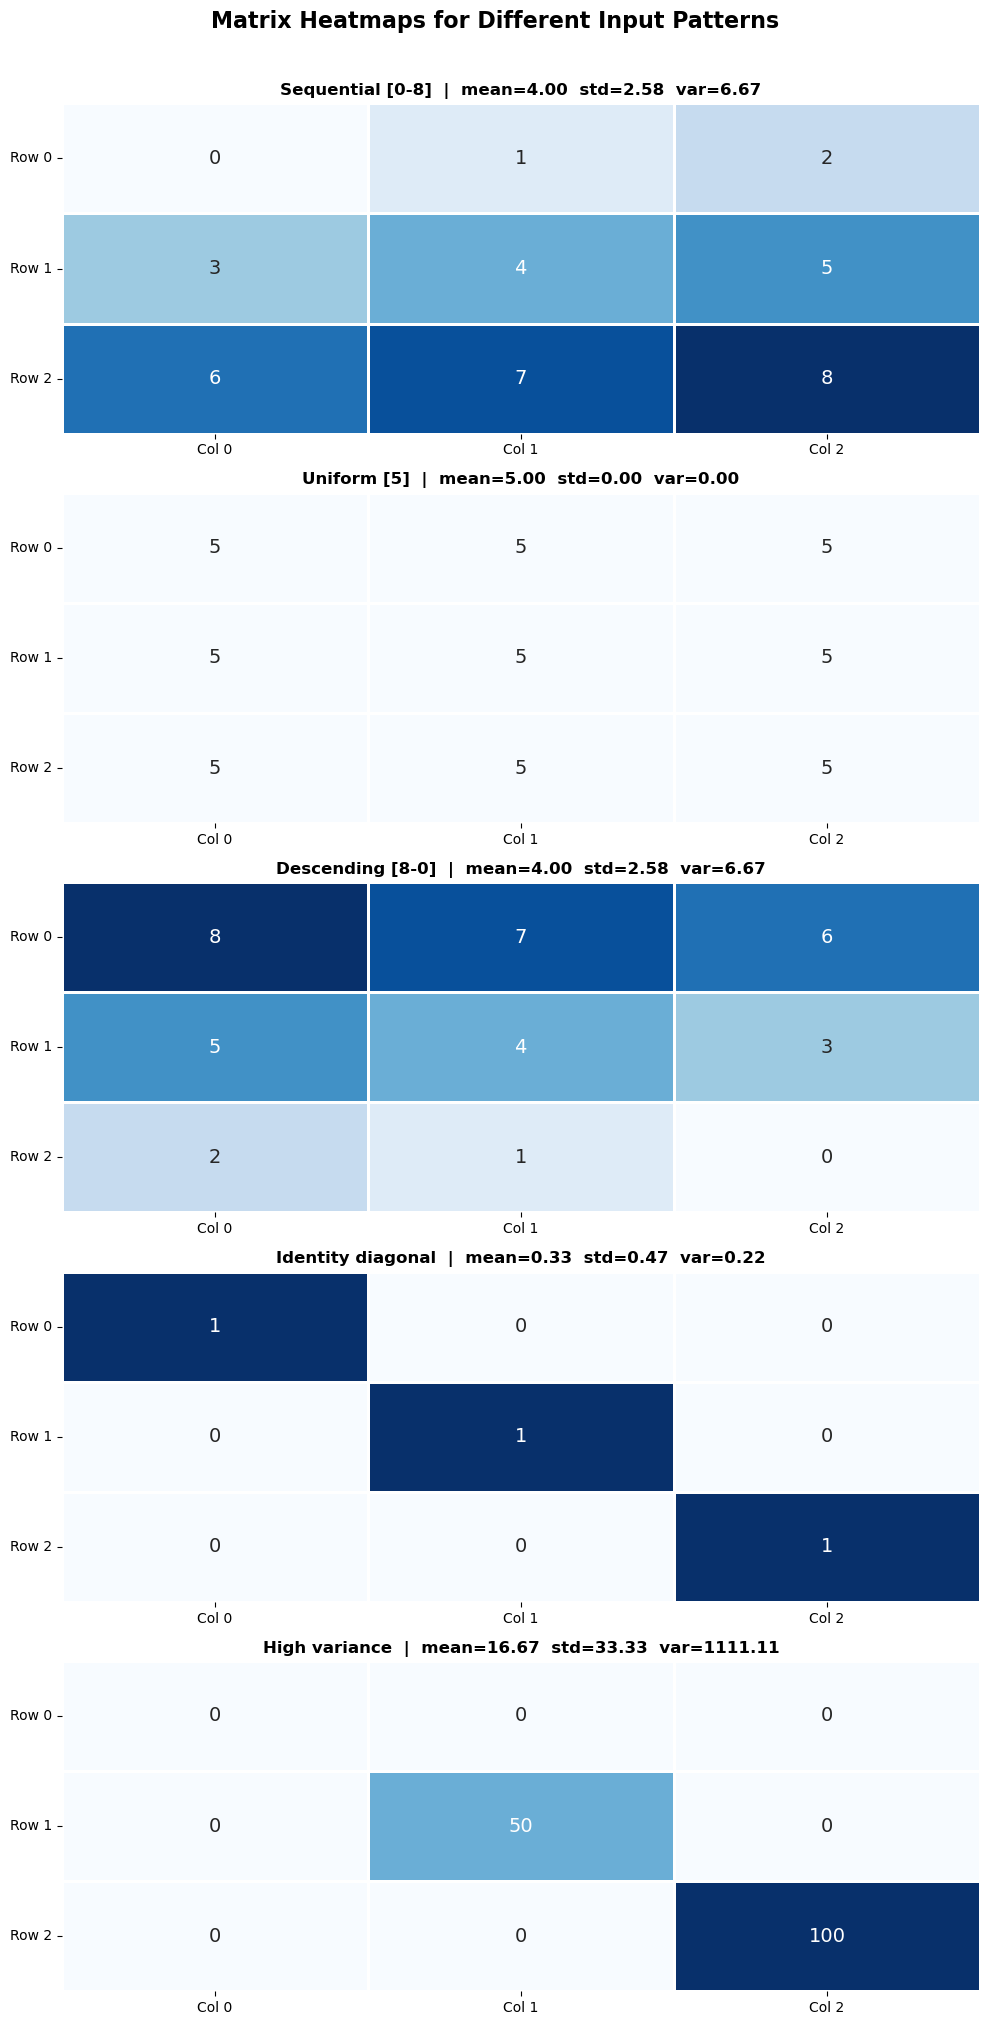

In [25]:
# Define several interesting test cases
test_cases = {
    'Sequential [0-8]'      : [0, 1, 2, 3, 4, 5, 6, 7, 8],
    'Uniform [5]'           : [5, 5, 5, 5, 5, 5, 5, 5, 5],
    'Descending [8-0]'      : [8, 7, 6, 5, 4, 3, 2, 1, 0],
    'Identity diagonal'     : [1, 0, 0, 0, 1, 0, 0, 0, 1],
    'High variance'         : [0, 0, 0, 0, 50, 0, 0, 0, 100],
}

fig, axes = plt.subplots(len(test_cases), 1, figsize=(10, 4 * len(test_cases)))

for ax, (label, lst) in zip(axes, test_cases.items()):
    res = calculate(lst)
    m   = np.array(lst).reshape(3, 3)

    sns.heatmap(m, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 14})
    ax.set_title(
        f"{label}  |  mean={res['mean'][2]:.2f}  "
        f"std={res['standard deviation'][2]:.2f}  "
        f"var={res['variance'][2]:.2f}",
        fontsize=12, fontweight='bold'
    )
    ax.set_xticklabels(['Col 0', 'Col 1', 'Col 2'])
    ax.set_yticklabels(['Row 0', 'Row 1', 'Row 2'], rotation=0)

plt.suptitle('Matrix Heatmaps for Different Input Patterns', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()